In [36]:
import dlt
import pandas as pd
import requests
from dlt.sources.helpers import requests as dlt_requests
import json
from datetime import datetime
import time

In [38]:
# Crear un CSV de ejemplo con ventas (simula fuente externa)
ventas_data = [
    {"venta_id": 1, "producto_id": 101, "cantidad": 2, "fecha": "2025-01-15"},
    {"venta_id": 2, "producto_id": 102, "cantidad": 1, "fecha": "2025-01-15"},
    {"venta_id": 3, "producto_id": 101, "cantidad": 3, "fecha": "2025-01-16"},
    {"venta_id": 4, "producto_id": 103, "cantidad": 5, "fecha": "2025-01-16"}
]
df_ventas = pd.DataFrame(ventas_data)
df_ventas.to_csv("ventas.csv", index=False)
print("Archivo ventas.csv creado")

Archivo ventas.csv creado


In [39]:
# Simulamos una API de productos (en realidad es una función que devuelve datos)
def get_products():
    # Simula una llamada HTTP
    products = [
        {"producto_id": 101, "nombre": "Laptop", "categoria": "Electrónica", "precio": 800},
        {"producto_id": 102, "nombre": "Mouse", "categoria": "Electrónica", "precio": 25},
        {"producto_id": 103, "nombre": "Teclado", "categoria": "Electrónica", "precio": 45}
    ]
    return products

@dlt.resource(primary_key="producto_id", write_disposition="merge")
def productos():
    # En un caso real aquí iría requests.get(...)
    data = get_products()
    for p in data:
        yield p

In [40]:
@dlt.resource(primary_key="venta_id", write_disposition="merge")
def ventas(incremental_ventas=dlt.sources.incremental("venta_id")):
    # Leer el CSV (simula un archivo que se actualiza externamente)
    df = pd.read_csv("ventas.csv")

    # Convertir a registros
    records = df.to_dict(orient="records")

    for v in records:
        # Si ya procesamos esta venta_id, la saltamos
        if incremental_ventas.last_value is not None and v["venta_id"] <= incremental_ventas.last_value:
            continue
        yield v

In [41]:
@dlt.transformer(data_from=ventas)
def ventas_con_producto(venta_item, productos_data):
    # productos_data es el recurso completo de productos (se pasa automáticamente)
    # Buscar el producto correspondiente
    producto = next((p for p in productos_data if p["producto_id"] == venta_item["producto_id"]), None)
    if producto:
        venta_item["nombre_producto"] = producto["nombre"]
        venta_item["precio_unitario"] = producto["precio"]
        venta_item["total_linea"] = venta_item["cantidad"] * producto["precio"]
    else:
        venta_item["nombre_producto"] = "DESCONOCIDO"
        venta_item["precio_unitario"] = 0
        venta_item["total_linea"] = 0
    yield venta_item

In [43]:
@dlt.transformer(data_from=ventas_con_producto)
def totales_por_producto(venta_item):
    # Este transformer agrupa, pero como dlt es orientado a flujo,
    # necesitamos acumular en memoria. Una forma más limpia es hacerlo en SQL después,
    # pero aquí mostramos cómo pasar datos enriquecidos.
    # Para este ejemplo, simplemente pasamos los datos enriquecidos y haremos la agregación en la tabla final.
    yield venta_item

In [44]:
# Definir el pipeline
pipeline = dlt.pipeline(
    pipeline_name="ecommerce_etl",
    destination="duckdb",
    dataset_name="ventas_analytics"
)

# Ejecutar la carga
load_info = pipeline.run(
    data=[
        (ventas_con_producto(productos_data=productos())) | totales_por_producto
    ]
)

print(load_info)

Pipeline ecommerce_etl load step completed in ---
0 load package(s) were loaded to destination duckdb and into dataset None
The duckdb destination used duckdb:////content/ecommerce_etl.duckdb location to store data


In [45]:
# Ver datos de ventas enriquecidas
with pipeline.sql_client() as client:
    result = client.execute_sql("SELECT * FROM totales_por_producto")
    for row in result:
        print(row)

(1, 101, 2, '2025-01-15', 'Laptop', 800, 1600, '1775742669.5506148', 'R0mQKKCkS2gk7g')
(2, 102, 1, '2025-01-15', 'Mouse', 25, 25, '1775742669.5506148', '+gwMwbu9JY4xFQ')
(3, 101, 3, '2025-01-16', 'Laptop', 800, 2400, '1775742669.5506148', 'vPOyiui8UjZglQ')
(4, 103, 5, '2025-01-16', 'Teclado', 45, 225, '1775742669.5506148', 'pdcRcrRIGrkfBQ')
(5, 102, 2, '2025-01-17', 'Mouse', 25, 50, '1775742779.2601132', 'tgH4syvJm3otKg')


In [46]:
with pipeline.sql_client() as client:
    result_grouped = client.execute_sql("SELECT nombre_producto, SUM(total_linea) as total_ventas FROM totales_por_producto GROUP BY nombre_producto")
    print("Total sales per product:")
    for row in result_grouped:
        print(row)

Total sales per product:
('Teclado', 225)
('Laptop', 4000)
('Mouse', 75)


In [47]:
# Simular una segunda ejecución: agregar una nueva venta al CSV
nueva_fila = pd.DataFrame([{"venta_id": 5, "producto_id": 102, "cantidad": 2, "fecha": "2025-01-17"}])
nueva_fila.to_csv("ventas.csv", mode='a', header=False, index=False)
print("Nueva venta agregada al CSV")

# Volver a ejecutar el pipeline (solo debe procesar la venta_id=5)
load_info2 = pipeline.run(
    data=[
        (ventas_con_producto(productos_data=productos())) | totales_por_producto
    ]
)
print("\n--- SEGUNDA EJECUCIÓN (INCREMENTAL) ---")
print(load_info2)

Nueva venta agregada al CSV

--- SEGUNDA EJECUCIÓN (INCREMENTAL) ---
Pipeline ecommerce_etl load step completed in ---
0 load package(s) were loaded to destination duckdb and into dataset None
The duckdb destination used duckdb:////content/ecommerce_etl.duckdb location to store data


In [48]:
with pipeline.sql_client() as client:
    result_grouped_after_incremental = client.execute_sql("SELECT nombre_producto, SUM(total_linea) as total_ventas FROM totales_por_producto GROUP BY nombre_producto")
    print("Total sales per product (after incremental load):")
    for row in result_grouped_after_incremental:
        print(row)

Total sales per product (after incremental load):
('Teclado', 225)
('Laptop', 4000)
('Mouse', 75)


In [49]:
# Verificar que no hay duplicados
with pipeline.sql_client() as client:
    count = client.execute_sql("SELECT COUNT(*) FROM totales_por_producto")[0][0]
    print(f"\nTotal registros en tabla totales_por_producto: {count} (deberían ser 5)")


Total registros en tabla totales_por_producto: 5 (deberían ser 5)


In [50]:
with pipeline.sql_client() as client:
    print("Distinct _dlt_load_ids in totales_por_producto table:")
    distinct_load_ids = client.execute_sql("SELECT DISTINCT _dlt_load_id FROM totales_por_producto")
    for load_id in distinct_load_ids:
        print(load_id[0])

Distinct _dlt_load_ids in totales_por_producto table:
1775742669.5506148
1775742779.2601132


In [51]:
with pipeline.sql_client() as client:
    print("Schema of totales_por_producto table:")
    schema_info = client.execute_sql("PRAGMA table_info(totales_por_producto)")
    for row in schema_info:
        print(row)

Schema of totales_por_producto table:
(0, 'venta_id', 'BIGINT', False, None, False)
(1, 'producto_id', 'BIGINT', False, None, False)
(2, 'cantidad', 'BIGINT', False, None, False)
(3, 'fecha', 'VARCHAR', False, None, False)
(4, 'nombre_producto', 'VARCHAR', False, None, False)
(5, 'precio_unitario', 'BIGINT', False, None, False)
(6, 'total_linea', 'BIGINT', False, None, False)
(7, '_dlt_load_id', 'VARCHAR', True, None, False)
(8, '_dlt_id', 'VARCHAR', True, None, False)


In [52]:
with pipeline.sql_client() as client:
    print("Metadata from _dlt_loads table:")
    # Select load_id, schema_name, and status from the _dlt_loads table
    load_metadata = client.execute_sql("SELECT load_id, schema_name, status, inserted_at FROM _dlt_loads ORDER BY inserted_at DESC")
    for row in load_metadata:
        print(row)

Metadata from _dlt_loads table:
('1775742779.2601132', 'ecommerce_etl', 0, datetime.datetime(2026, 4, 9, 13, 52, 59, 530425, tzinfo=<UTC>))
('1775742669.5506148', 'ecommerce_etl', 0, datetime.datetime(2026, 4, 9, 13, 51, 10, 89960, tzinfo=<UTC>))


In [53]:
with pipeline.sql_client() as client:
    print("Available tables in the DuckDB database:")
    tables = client.execute_sql("PRAGMA show_tables;")
    for row in tables:
        print(row[0])

Available tables in the DuckDB database:
_dlt_loads
_dlt_pipeline_state
_dlt_version
totales_por_producto


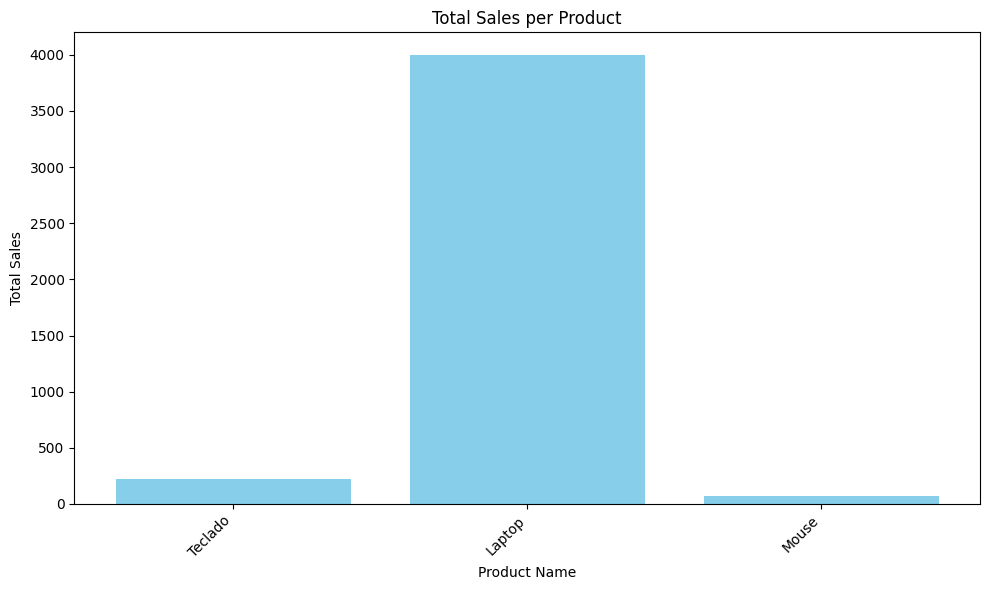

In [54]:
import matplotlib.pyplot as plt

# Extract product names and total sales from the result
product_names = [row[0] for row in result_grouped_after_incremental]
total_sales = [row[1] for row in result_grouped_after_incremental]

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(product_names, total_sales, color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.title('Total Sales per Product')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [55]:
with pipeline.sql_client() as client:
    count = client.execute_sql("SELECT COUNT(*) FROM totales_por_producto")[0][0]
    print(f"Total records in 'totales_por_producto' table: {count}")

Total records in 'totales_por_producto' table: 5


In [56]:
with pipeline.sql_client() as client:
    result = client.execute_sql("SELECT * FROM totales_por_producto LIMIT 10")
    print("First 10 rows from totales_por_producto:")
    for row in result:
        print(row)

First 10 rows from totales_por_producto:
(1, 101, 2, '2025-01-15', 'Laptop', 800, 1600, '1775742669.5506148', 'R0mQKKCkS2gk7g')
(2, 102, 1, '2025-01-15', 'Mouse', 25, 25, '1775742669.5506148', '+gwMwbu9JY4xFQ')
(3, 101, 3, '2025-01-16', 'Laptop', 800, 2400, '1775742669.5506148', 'vPOyiui8UjZglQ')
(4, 103, 5, '2025-01-16', 'Teclado', 45, 225, '1775742669.5506148', 'pdcRcrRIGrkfBQ')
(5, 102, 2, '2025-01-17', 'Mouse', 25, 50, '1775742779.2601132', 'tgH4syvJm3otKg')
